In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
!pip3 install plotly


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [3]:
file_path = 'SpotifyFeatures.csv' 
df = pd.read_csv(file_path)

print("--- Перші 5 рядків датасету ---")
display(df.head())

print("\n--- Статистика числових колонок ---")
display(df.describe())

numeric_features = [
    'danceability', 'energy', 'loudness', 'speechiness', 
    'acousticness', 'instrumentalness', 'liveness', 'valence', 
    'tempo', 'duration_ms'
]

scaler = StandardScaler()

df_scaled = df.copy()
df_scaled[numeric_features] = scaler.fit_transform(df[numeric_features])

df_popular = df_scaled[df_scaled['popularity'] >= 85].copy()

print(f"\n--- Розмірність таблиці після фільтрації ---")
print(f"Кількість рядків (треків): {df_popular.shape[0]}")
print(f"Кількість колонок (ознак): {df_popular.shape[1]}")

--- Перші 5 рядків датасету ---


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390



--- Статистика числових колонок ---


,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000



--- Розмірність таблиці після фільтрації ---
Кількість рядків (треків): 417
Кількість колонок (ознак): 18


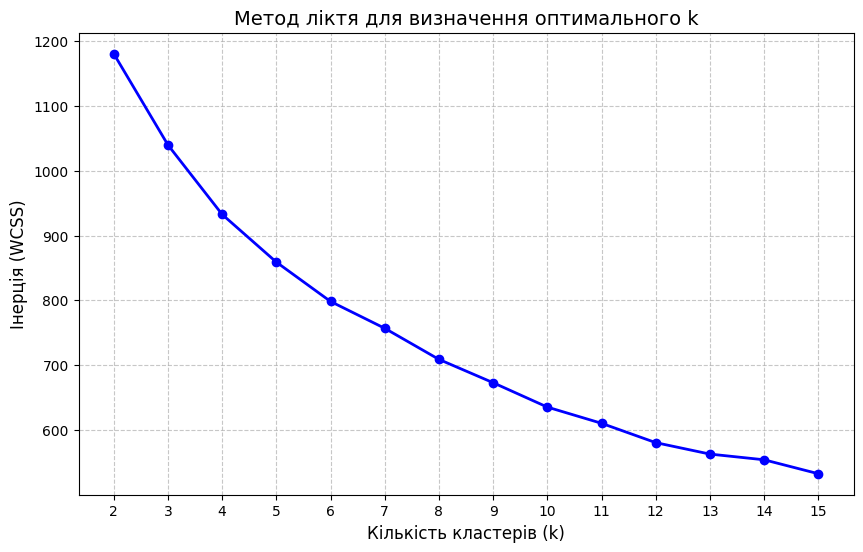

In [4]:
X = df_popular[numeric_features]

inertia = []

k_range = range(2, 16)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    kmeans.fit(X)
    
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='-', color='b', linewidth=2)

plt.title('Метод ліктя для визначення оптимального k', fontsize=14)
plt.xlabel('Кількість кластерів (k)', fontsize=12)
plt.ylabel('Інерція (WCSS)', fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

In [5]:
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)

cluster_labels = kmeans_final.fit_predict(df_popular[numeric_features])

df_popular['cluster'] = cluster_labels

print("--- Кількість треків у кожному кластері ---")
cluster_counts = df_popular['cluster'].value_counts().sort_index()
print(cluster_counts)

print("\n--- Середні характеристики кожного кластера ---")
display(df_popular.groupby('cluster')[numeric_features].mean())

--- Кількість треків у кожному кластері ---
cluster
0     75
1     72
2    130
3     92
4     48
Name: count, dtype: int64

--- Середні характеристики кожного кластера ---


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
cluster,,,,,,,,,,
0,1.047633,0.405745,0.649717,0.228479,-0.762124,-0.484680,-0.244109,0.705272,1.258256,-0.258762
1,1.752557,-0.258686,0.283358,0.506466,-0.547397,-0.478156,-0.055113,-0.092232,-0.335818,-0.331752
2,0.765494,0.583095,0.816319,-0.169901,-0.447590,-0.488563,-0.394687,0.460619,-0.519791,-0.338341
3,0.608311,0.329810,0.621947,-0.198298,-0.565930,-0.482929,-0.062395,-0.556828,0.870198,-0.198100
4,0.326237,-0.423615,0.298130,0.100707,0.425490,-0.450808,-0.298101,-0.400534,-0.889462,-0.273801


In [6]:
!pip3 install --upgrade nbformat


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [7]:
pca_2d = PCA(n_components=2, random_state=42)
pca_features_2d = pca_2d.fit_transform(df_popular[numeric_features])

df_popular['PCA1'] = pca_features_2d[:, 0]
df_popular['PCA2'] = pca_features_2d[:, 1]

df_popular['cluster_name'] = 'Cluster ' + df_popular['cluster'].astype(str)

fig_2d = px.scatter(
    df_popular, 
    x='PCA1', 
    y='PCA2', 
    color='cluster_name',
    title='2D Візуалізація кластерів популярних треків (PCA)',
    opacity=0.8,
)

fig_2d.update_layout(
    xaxis_title=f"Головна компонента 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)",
    yaxis_title=f"Головна компонента 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)"
)

fig_2d.show()



pca_3d = PCA(n_components=3, random_state=42)
pca_features_3d = pca_3d.fit_transform(df_popular[numeric_features])

df_popular['PCA3'] = pca_features_3d[:, 2]

fig_3d = px.scatter_3d(
    df_popular, 
    x='PCA1', 
    y='PCA2', 
    z='PCA3',
    color='cluster_name',
    title='3D Візуалізація кластерів (PCA)',
    opacity=0.7
)

fig_3d.update_traces(marker=dict(size=4))
fig_3d.show()

--- Середні значення ознак по кластерах (стандартизовані) ---


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
cluster,,,,,,,,,,
0,1.047633,0.405745,0.649717,0.228479,-0.762124,-0.484680,-0.244109,0.705272,1.258256,-0.258762
1,1.752557,-0.258686,0.283358,0.506466,-0.547397,-0.478156,-0.055113,-0.092232,-0.335818,-0.331752
2,0.765494,0.583095,0.816319,-0.169901,-0.447590,-0.488563,-0.394687,0.460619,-0.519791,-0.338341
3,0.608311,0.329810,0.621947,-0.198298,-0.565930,-0.482929,-0.062395,-0.556828,0.870198,-0.198100
4,0.326237,-0.423615,0.298130,0.100707,0.425490,-0.450808,-0.298101,-0.400534,-0.889462,-0.273801


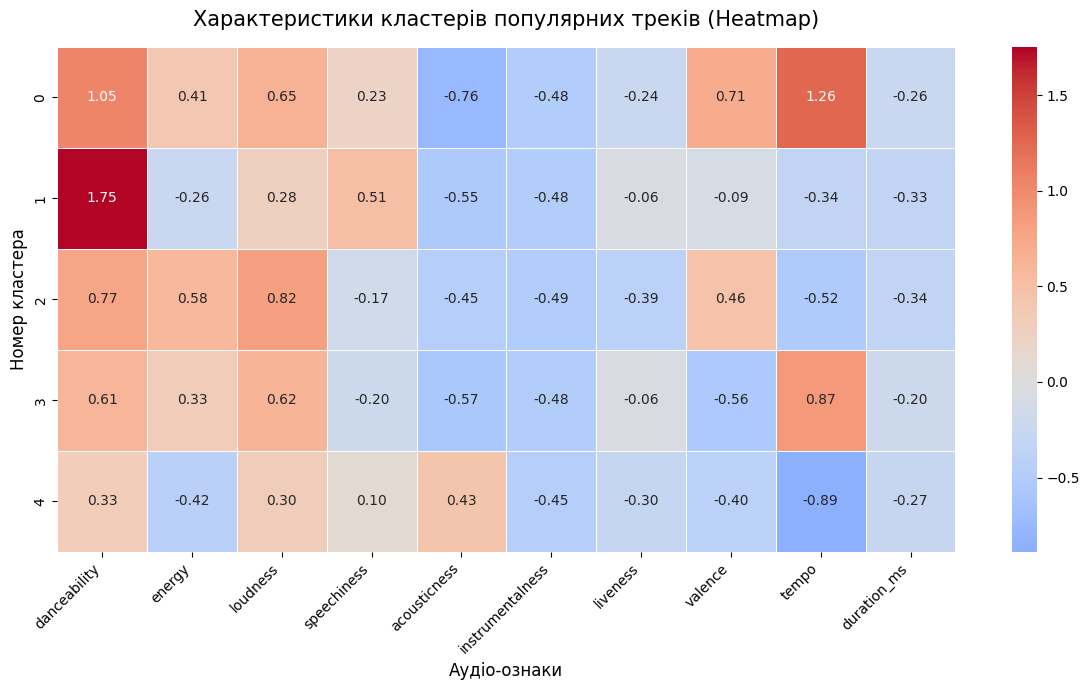

In [8]:
cluster_means = df_popular.groupby('cluster')[numeric_features].mean()

print("--- Середні значення ознак по кластерах (стандартизовані) ---")
display(cluster_means)

plt.figure(figsize=(12, 7))

sns.heatmap(cluster_means, annot=True, cmap='coolwarm', fmt=".2f", center=0, linewidths=0.5)

plt.title('Характеристики кластерів популярних треків (Heatmap)', fontsize=15, pad=15)
plt.ylabel('Номер кластера', fontsize=12)
plt.xlabel('Аудіо-ознаки', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()